In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 1.Data Cleaning

In [2]:
df = pd.read_csv("../data/raw/cpi_canada.csv")

In [3]:
df = df.rename(columns={
    "observation_date": "Date",
    "CPALCY01CAM661N": "CPI"
})
df.head()

,Date,CPI
0,1961-01-01,13.428804
1,1961-02-01,13.428804
2,1961-03-01,13.377873
3,1961-04-01,13.343919
4,1961-05-01,13.259034


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    755 non-null    datetime64[us]
 1   CPI     755 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.9 KB


In [5]:
"""Make sure the data is sorted"""
df = df.sort_values("Date")

df.head()

,Date,CPI
0,1961-01-01,13.428804
1,1961-02-01,13.428804
2,1961-03-01,13.377873
3,1961-04-01,13.343919
4,1961-05-01,13.259034


### Data Cleaning

In this section, I prepared the dataset for analysis.

I renamed the columns to improve readability, converted the date column into a datetime format, and sort the data by date.

These steps improve code readability and ensure the dataset is ready for time series analysis.

## 2.EDA step

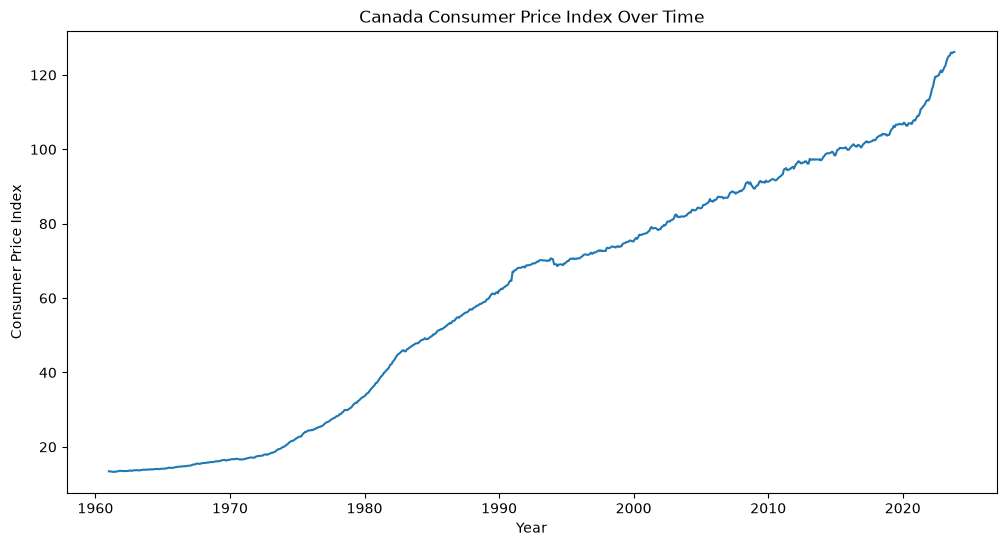

In [7]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["CPI"])

plt.title("Canada Consumer Price Index Over Time")

plt.xlabel("Year")

plt.ylabel("Consumer Price Index")

plt.savefig("../images/cpi_over_time.png", dpi=300)

plt.show()

### Exploratory Data Analysis

I created a line chart to visualize the Consumer Price Index (CPI) over time in Canada.

The chart helps identify long-term trends and changes in the price level. Plotting the data before performing further analysis allows us to understand the overall behavior of the dataset.

## 3.Feature Engineering

In [11]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df.head()


,Date,CPI,Year,Month
0,1961-01-01,13.428804,1961,1
1,1961-02-01,13.428804,1961,2
2,1961-03-01,13.377873,1961,3
3,1961-04-01,13.343919,1961,4
4,1961-05-01,13.259034,1961,5


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 755 entries, 0 to 754
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    755 non-null    datetime64[us]
 1   CPI     755 non-null    float64       
 2   Year    755 non-null    int32         
 3   Month   755 non-null    int32         
dtypes: datetime64[us](1), float64(1), int32(2)
memory usage: 17.8 KB


In [13]:
df["Year"].nunique()

63

In [15]:
df["Year"].unique()

array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], dtype=int32)

### Feature Engineering

This secion, I extract the year and month from the Data using panadas' `.dt`. These new variables make the dataset easier to analysis.